# Para esta Tarea

## Generar un archivo tipo Notebook de Python que contenga : 

- La definición de un modelo determinístico de un cálculo de costos: presupuesto simple con ítems, suma uno a uno.
    - Definición de distribuciones de probabilidad a las variables del modelo
    - Ejecución de simulación aplicada al modelo con 5000 iteraciones
    - Lectura e interpretación de resultados
    - Visualización básica y conclusions
    - Análisis de sensibilidad con dos tipos de distribución diferentes
    - Conclusiones finales

## Importacion de librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Modelo determinístico simple
items = {
    'materiales': 5000,
    'mano_obra': 8000,
    'transporte': 1500,
    'impuestos': 2000,
}

costo_total = sum(items.values())
costo_total

16500

## Distribuciones de Probabilidad

In [3]:
# Normal
def normal(loc, scale, size=1):
    return np.random.normal(loc, scale, size)

# Uniforme
def uniforme(low, high, size=1):
    return np.random.uniform(low, high, size)

# Triangular
def triangular(min_val, mode, max_val, size=1):
    return np.random.triangular(min_val, mode, max_val, size)

In [ ]:
interaciones = 5000
simulaciones = []

for i in range(interaciones):
    total = (
        normal(5000, 300) +
        triangular(7000, 8500, 10000) +   # min, mode, max
        uniforme(1000, 1800) +
        normal(2000, 200)
    )
    simulaciones.append(total.item())

simulaciones = np.array(simulaciones)

np.mean(simulaciones), np.std(simulaciones)


(np.float64(16921.409410721324), np.float64(743.9052678580621))

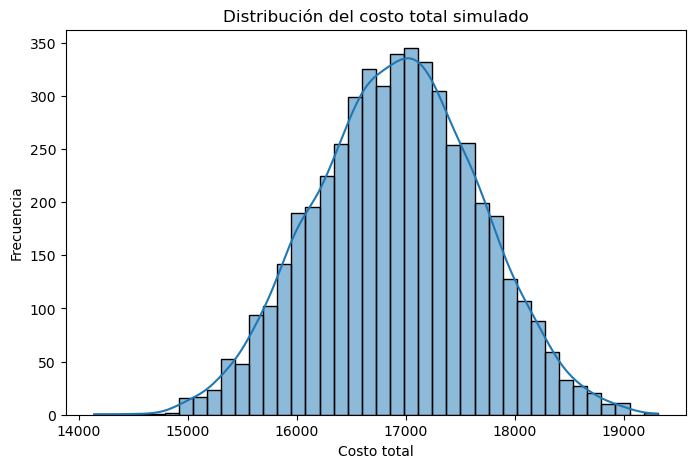

In [5]:
# Visualización de resultados
plt.figure(figsize=(8,5))
sns.histplot(simulaciones, bins=40, kde=True)
plt.title("Distribución del costo total simulado")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.show()


## Analisis de Sensibilidad

In [6]:
sim_triangular = []
sim_normal = []

for _ in range(interaciones):

    # --- Triangular ---
    total_tri = (
        normal(5000, 300) +
        triangular(7000, 8500, 10000) +
        uniforme(1000, 1800) +
        normal(2000, 200)
    )
    sim_triangular.append(total_tri.item())
    
    # --- Normal ---
    total_norm = (
        normal(5000, 300) +
        normal(8000, 600) +
        uniforme(1000, 1800) +
        normal(2000, 200)
    )
    sim_normal.append(total_norm.item())

sim_triangular = np.array(sim_triangular)
sim_normal = np.array(sim_normal)


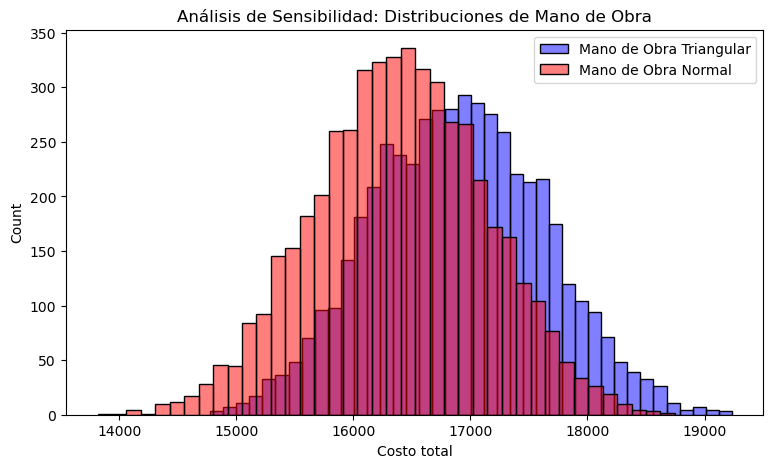

In [7]:
plt.figure(figsize=(9,5))
sns.histplot(sim_triangular, bins=40, color="blue", alpha=0.5, label="Mano de Obra Triangular")
sns.histplot(sim_normal, bins=40, color="red", alpha=0.5, label="Mano de Obra Normal")
plt.title("Análisis de Sensibilidad: Distribuciones de Mano de Obra")
plt.xlabel("Costo total")
plt.legend()
plt.show()

## Conclusiones

- La simulación revela la variabilidad del costo total cuando los insumos no son fijos.
- La variable con mayor impacto es **mano de obra**, debido a su rango amplio.
- Cambiar la distribución de mano de obra (triangular → normal) modifica la dispersión total del presupuesto.
- La simulación Monte Carlo permite evaluar riesgos en presupuestos y crear rangos confiables.
- El uso de distribuciones manuales con NumPy es suficiente para análisis probabilísticos simples.
